# import

In [1]:
# 사용할 패키지를 import합니다
import sys
print('python', sys.version)

import numpy as np
print('numpy', np.__version__)

import pandas as pd
print('pandas', pd.__version__)

import matplotlib as mpl
print('matplotlib', mpl.__version__)

import matplotlib.pyplot as plt

import seaborn as sns
print('pandas', sns.__version__)

# 결과 확인을 용이하게 하기 위한 코드
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# figure에 한글 폰트 사용을 위한 코드
plt.rc("font", family="Malgun Gothic") # window
#plt.rc("font", family="AppleGothic") # mac
from matplotlib.ticker import MaxNLocator

python 3.13.6 (tags/v3.13.6:4e66535, Aug  6 2025, 14:36:00) [MSC v.1944 64 bit (AMD64)]
numpy 2.4.2
pandas 3.0.1
matplotlib 3.10.8
pandas 0.13.2


# 과제1

* 주어진 df1에 아래 4개의 각 과정을 수행한 결과(df_res)를 출력하고, df_res를 아래와 같이 다중그래프로 나타내시오
* 1) "분양가격" column 전체를 float형으로 변경하시오 (단, "\_"이 포함되어있는 값들에 대해서, "\_"를 제거하고, float형으로 변경하시오)
* 2) "전용면적"이 "전체"인 행을 제거하시오
* 3) "전용면적"이 '\~60', "60\~85" 은 'small'로 '85\~102','102\~'은 'large'로 값을 변경하시오
* 4) 지역별, 전용면적 별로 그룹을 만들고 각 그룹의 분양가격의 평균보다 큰 분양가격들 중에 최소 평당분양가격을 구하시오 ==> df_res

## original df1
## step1
## step2
## step3


,지역명,연도,월,분양가격,전용면적
0,전남,2022,5,10157.4,small
1,전남,2022,11,11107.8,small
2,광주,2020,6,14127.3,large
3,광주,2020,7,15213.0,large
4,전남,2020,6,12292.0,large
...,...,...,...,...,...
92,충북,2020,4,7887.0,small
94,광주,2019,12,12955.8,small
96,충북,2021,7,9075.0,large
97,광주,2019,8,12276.0,small


## step4
## 다중그래프 그리기


C:\Users\박민경\AppData\Local\Temp\ipykernel_14088\78072366.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _=ax1.legend(bbox_to_anchor=(1,1), loc='upper left')


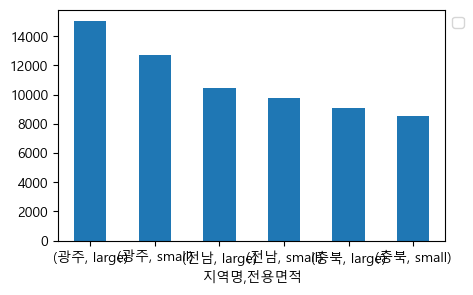

In [2]:
df1=pd.read_table('data/proj1_data.txt', index_col=0)
print('## original df1')


print('## step1')
df1['분양가격'] = df1['분양가격'].str.replace('_', '').astype(float)

print('## step2')
## 코드작성
df2= df1[df1['전용면적'] != '전체']

print('## step3')
df2=df2.copy()
df2['전용면적']=df2['전용면적'].replace({'~60': 'small', '60~85': 'small', '85~102': 'large', '102~': 'large'})
df2

print('## step4')
## 코드작성
def get_min_above_avg(group):
    avg = group['분양가격'].mean()
    return group[group['분양가격'] > avg]['분양가격'].min()
df_res= df2.groupby(['지역명', '전용면적']).apply(get_min_above_avg)

print('## 다중그래프 그리기')
fig=plt.figure(figsize=(5,3))
ax1 = fig.subplots()

_=df_res.plot.bar(ax=ax1, rot=0)
_=ax1.legend(bbox_to_anchor=(1,1), loc='upper left')
